# Traffic Analytics Platform

This notebook walks through loading, cleaning, feature engineering, exploratory analysis, and export of the traffic analytics dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_excel("../data/traffic_analytics_dataset_10000.xlsx")

In [ ]:
df.head()

## Step 4: Understand the Dataset

Use these cells to inspect shape, columns, data types, and summary statistics.

In [3]:
print("Shape:", df.shape)
print("Columns:")
print(df.columns)
print()
print("Data Types:")
df.info()
print()
print("Statistical Summary:")
df.describe()

Shape: (10000, 15)
Columns:
Index(['datetime', 'road_id', 'junction', 'vehicle_count', 'avg_speed_kmph',
       'signal_delay_sec', 'temperature_c', 'rainfall_mm', 'weather',
       'holiday', 'weekday', 'hour', 'congestion_level', 'latitude',
       'longitude'],
      dtype='object')

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   datetime          10000 non-null  object 
 1   road_id           10000 non-null  object 
 2   junction          10000 non-null  object 
 3   vehicle_count     10000 non-null  int64  
 4   avg_speed_kmph    10000 non-null  float64
 5   signal_delay_sec  10000 non-null  float64
 6   temperature_c     10000 non-null  float64
 7   rainfall_mm       10000 non-null  float64
 8   weather           10000 non-null  object 
 9   holiday           10000 non-null  int64  
 10  weekday           10000

,vehicle_count,avg_speed_kmph,signal_delay_sec,temperature_c,rainfall_mm,holiday,hour,latitude,longitude
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,263.179000,46.496350,11.782230,12.778560,1.224910,0.039600,11.493600,28.614092,77.208670
std,174.849515,12.045522,12.150726,10.363969,3.636383,0.195027,6.921297,0.046087,0.046011
min,40.000000,10.000000,5.000000,-6.000000,0.000000,0.000000,0.000000,28.533914,77.129008
25%,145.000000,39.900000,5.000000,2.600000,0.000000,0.000000,5.000000,28.574128,77.168801
50%,195.000000,51.100000,5.000000,14.200000,0.000000,0.000000,11.000000,28.614325,77.208607
75%,260.000000,54.800000,10.900000,22.025000,0.000000,0.000000,17.000000,28.653261,77.248684
max,760.000000,65.900000,54.500000,30.000000,18.000000,1.000000,23.000000,28.693900,77.288997


**Interview question:** Why do we use `describe()`?

**Answer:** It helps understand the distribution of numerical variables such as mean, min, max, standard deviation, and quartiles.

## Step 5: Data Cleaning

Check for missing values, duplicate observations, and convert the datetime column to a proper datetime type.

In [4]:
missing_values = df.isnull().sum()
print(missing_values)
if missing_values.sum() == 0:
    print("No missing values were found.")

duplicate_count = df.duplicated().sum()
print(duplicate_count)
if duplicate_count == 0:
    print("Dataset contains no duplicate observations.")

datetime            0
road_id             0
junction            0
vehicle_count       0
avg_speed_kmph      0
signal_delay_sec    0
temperature_c       0
rainfall_mm         0
weather             0
holiday             0
weekday             0
hour                0
congestion_level    0
latitude            0
longitude           0
dtype: int64
No missing values were found.
0
Dataset contains no duplicate observations.


In [5]:
df["datetime"] = pd.to_datetime(df["datetime"])
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.day_name()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          10000 non-null  datetime64[ns]
 1   road_id           10000 non-null  object        
 2   junction          10000 non-null  object        
 3   vehicle_count     10000 non-null  int64         
 4   avg_speed_kmph    10000 non-null  float64       
 5   signal_delay_sec  10000 non-null  float64       
 6   temperature_c     10000 non-null  float64       
 7   rainfall_mm       10000 non-null  float64       
 8   weather           10000 non-null  object        
 9   holiday           10000 non-null  int64         
 10  weekday           10000 non-null  object        
 11  hour              10000 non-null  int32         
 12  congestion_level  10000 non-null  object        
 13  latitude          10000 non-null  float64       
 14  longitude         10000

## Step 6: Feature Engineering

Create calendar-based and traffic-intensity features for richer analysis.

In [6]:
df["Month"] = df["datetime"].dt.month_name()
df["Date"] = df["datetime"].dt.date
df["Year"] = df["datetime"].dt.year

def peak(hour):
    if 7 <= hour <= 10:
        return "Morning Peak"
    elif 17 <= hour <= 20:
        return "Evening Peak"
    return "Normal"

df["Peak_Hour"] = df["hour"].apply(peak)
df["Weekend"] = df["weekday"].isin(["Saturday", "Sunday"])
df["Rush_Hour"] = np.where(df["vehicle_count"] > 500, "Yes", "No")

## Step 7: Exploratory Data Analysis (EDA)

The next cells answer the main business and traffic-pattern questions.

In [7]:
total_vehicles = df["vehicle_count"].sum()
average_speed = df["avg_speed_kmph"].mean()
average_signal_delay = df["signal_delay_sec"].mean()
hourly = df.groupby("hour")["vehicle_count"].mean()

print("Total Vehicles:", total_vehicles)
print("Average Speed:", average_speed)
print("Average Signal Delay:", average_signal_delay)
hourly

Total Vehicles: 2631790
Average Speed: 46.49635000000001
Average Signal Delay: 11.782229999999998


hour
0     167.573141
1     167.494005
2     170.659472
3     166.047962
4     167.467626
5     170.549161
6     168.935252
7     549.136691
8     544.719424
9     549.489209
10    170.729017
11    171.122302
12    170.820144
13    165.767386
14    167.877698
15    168.249400
16    171.153846
17    545.057692
18    543.031250
19    544.670673
20    165.127404
21    167.733173
22    172.685096
23    171.098558
Name: vehicle_count, dtype: float64

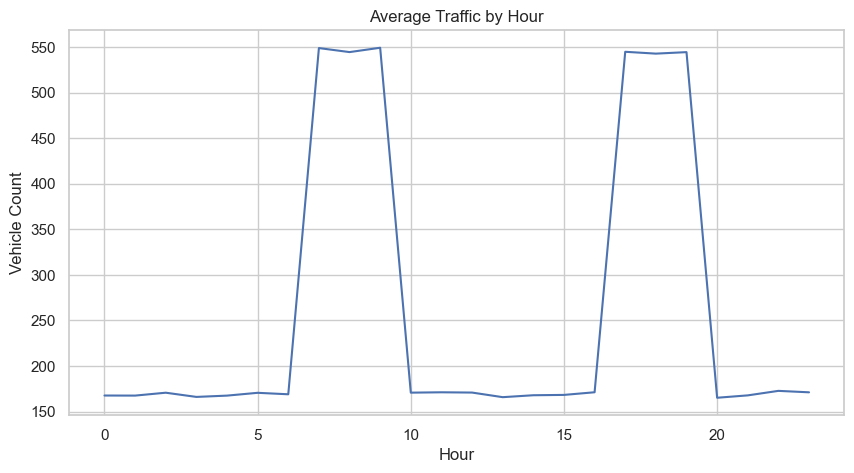

In [8]:
hourly.plot(figsize=(10, 5))
plt.title("Average Traffic by Hour")
plt.xlabel("Hour")
plt.ylabel("Vehicle Count")
plt.grid(True)
plt.show()

Traffic volume typically peaks during 8–9 AM and 5–7 PM, which indicates commuter rush hours.

In [ ]:
weekday = df.groupby("weekday")["vehicle_count"].mean()
weekday.plot(kind="bar", figsize=(10, 5))
plt.title("Average Traffic by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Vehicle Count")
plt.xticks(rotation=45)
plt.show()

df["congestion_level"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(7, 7))
plt.title("Congestion Level Distribution")
plt.ylabel("")
plt.show()

Monday often records the highest traffic volume while weekends remain lower. Most observations fall into the medium congestion category.

weather
Clear     268.728640
Cloudy    264.919083
Fog       264.319703
Rain      232.169046
Name: vehicle_count, dtype: float64


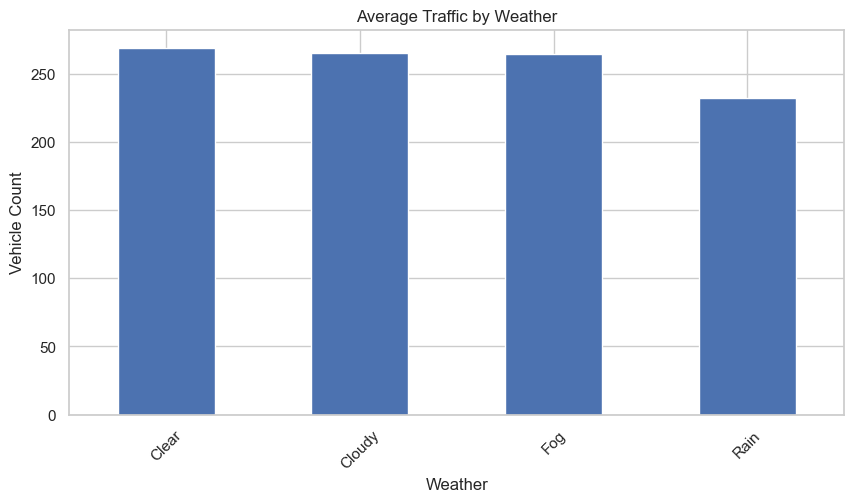

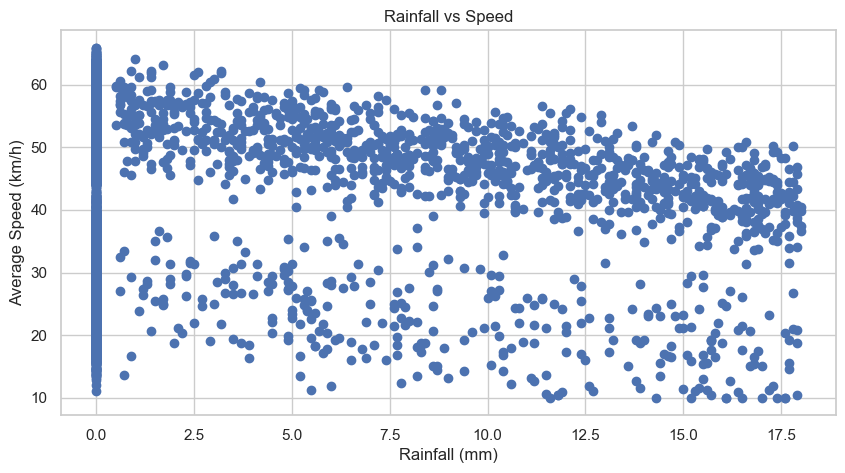

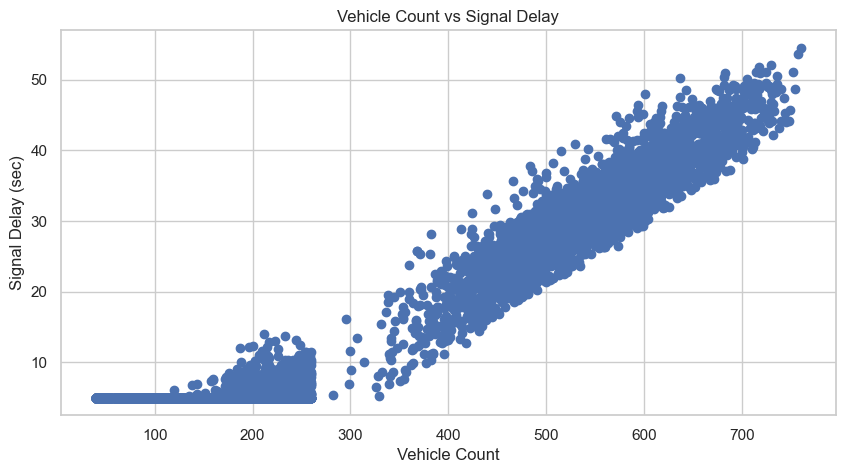

In [9]:
weather = df.groupby("weather")["vehicle_count"].mean()
print(weather)
weather.plot(kind="bar", figsize=(10, 5))
plt.title("Average Traffic by Weather")
plt.xlabel("Weather")
plt.ylabel("Vehicle Count")
plt.xticks(rotation=45)
plt.show()

plt.scatter(df["rainfall_mm"], df["avg_speed_kmph"])
plt.title("Rainfall vs Speed")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Average Speed (km/h)")
plt.show()

plt.scatter(df["vehicle_count"], df["signal_delay_sec"])
plt.title("Vehicle Count vs Signal Delay")
plt.xlabel("Vehicle Count")
plt.ylabel("Signal Delay (sec)")
plt.show()

Rainy weather generally reduces traffic volume and average speed. Higher vehicle counts are associated with longer signal delays.

road_id
R030    284.093168
R020    278.059006
R028    277.947977
R023    276.907514
R021    273.275401
R017    271.849558
R014    271.452941
R006    271.214744
R001    268.482249
R019    265.603960
Name: vehicle_count, dtype: float64


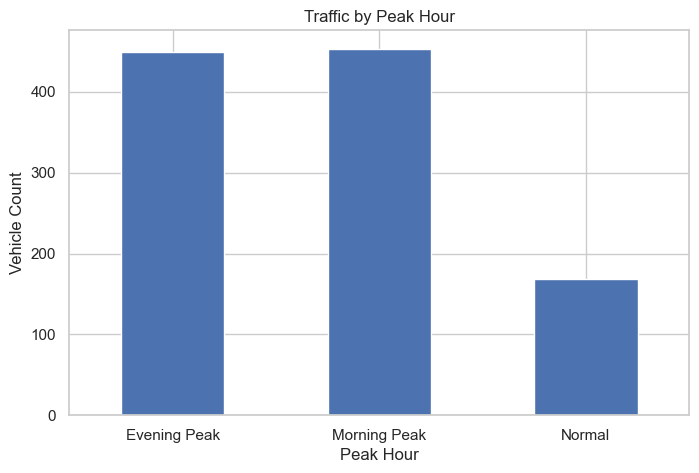

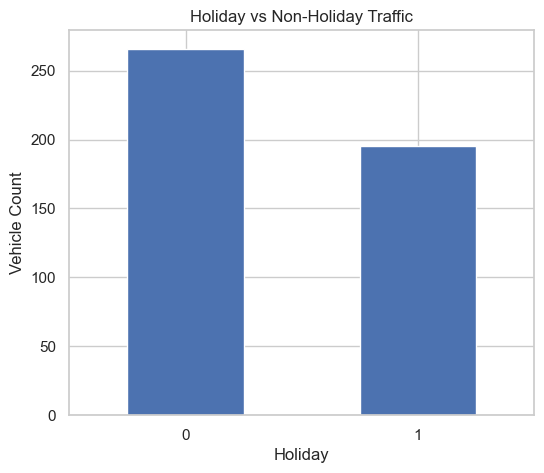

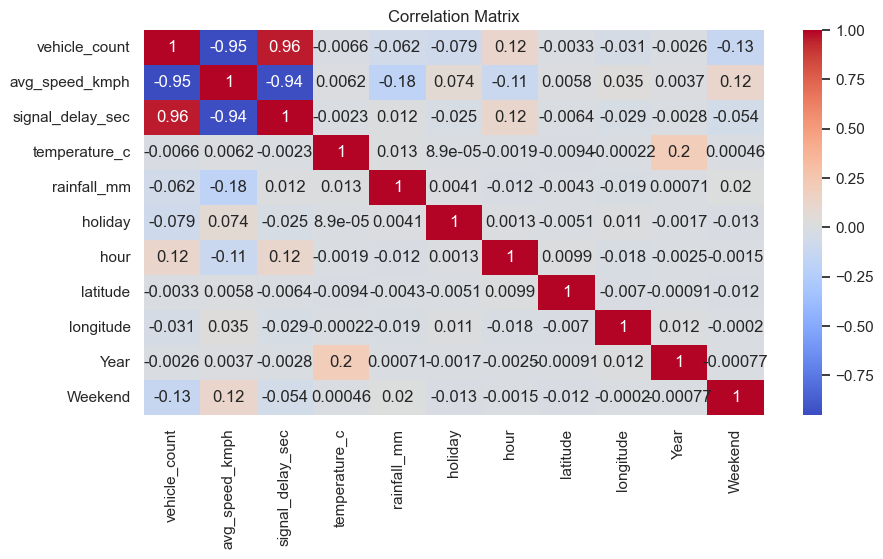

In [10]:
roads = df.groupby("road_id")["vehicle_count"].mean()
print(roads.sort_values(ascending=False).head(10))

df.groupby("Peak_Hour")["vehicle_count"].mean().plot(kind="bar", figsize=(8, 5))
plt.title("Traffic by Peak Hour")
plt.xlabel("Peak Hour")
plt.ylabel("Vehicle Count")
plt.xticks(rotation=0)
plt.show()

df.groupby("holiday")["vehicle_count"].mean().plot(kind="bar", figsize=(6, 5))
plt.title("Holiday vs Non-Holiday Traffic")
plt.xlabel("Holiday")
plt.ylabel("Vehicle Count")
plt.xticks(rotation=0)
plt.show()

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Busy roads remain consistently active, Morning and Evening Peak periods show the highest volumes, holidays are typically quieter, and the strongest correlations are usually between vehicle count, signal delay, speed, and rainfall.

In [11]:
df.to_excel("../data/Cleaned_Traffic_Data.xlsx", index=False)
print("Cleaned_Traffic_Data.xlsx saved to the data folder.")

Cleaned_Traffic_Data.xlsx saved to the data folder.


## Step 8: Export

The cleaned dataset is saved as `Cleaned_Traffic_Data.xlsx` in the `data/` folder.